# Medical Insurance Cost Predictor

### Exploratory Data Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 1. Load & Inspect Data


In [2]:
insurance = pd.read_csv("data/insurance.csv")
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# column types and missing values
insurance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
# summary statistics
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 2. Target Distribution


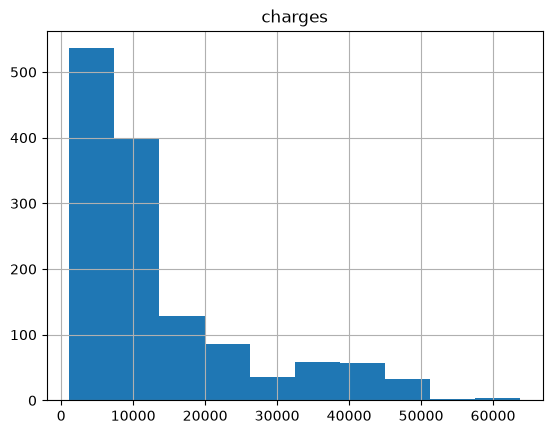

In [5]:
# charges is right-skewed — most people pay low costs but a few pay very high
insurance.hist('charges')
plt.show()

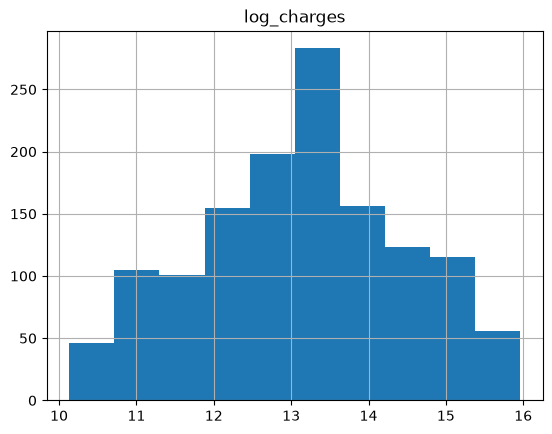

In [6]:
# log-transform charges to normalize the target
insurance["log_charges"] = np.log2(insurance["charges"])
insurance.hist('log_charges')
plt.show()

## 3. Correlation Heatmap


<Axes: >

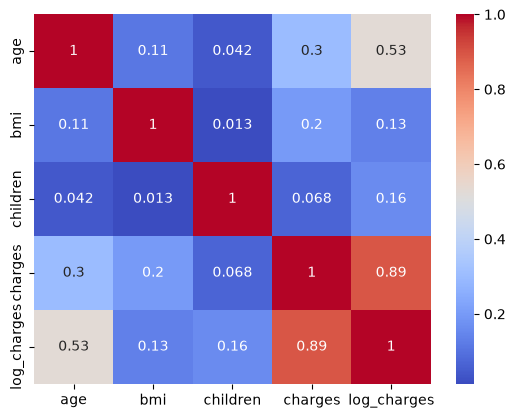

In [7]:
# age and bmi correlate most with charges
correlation = insurance.select_dtypes(include=np.number).corr()
sns.heatmap(correlation, cmap='coolwarm', annot=True)

## 4. Pairplot


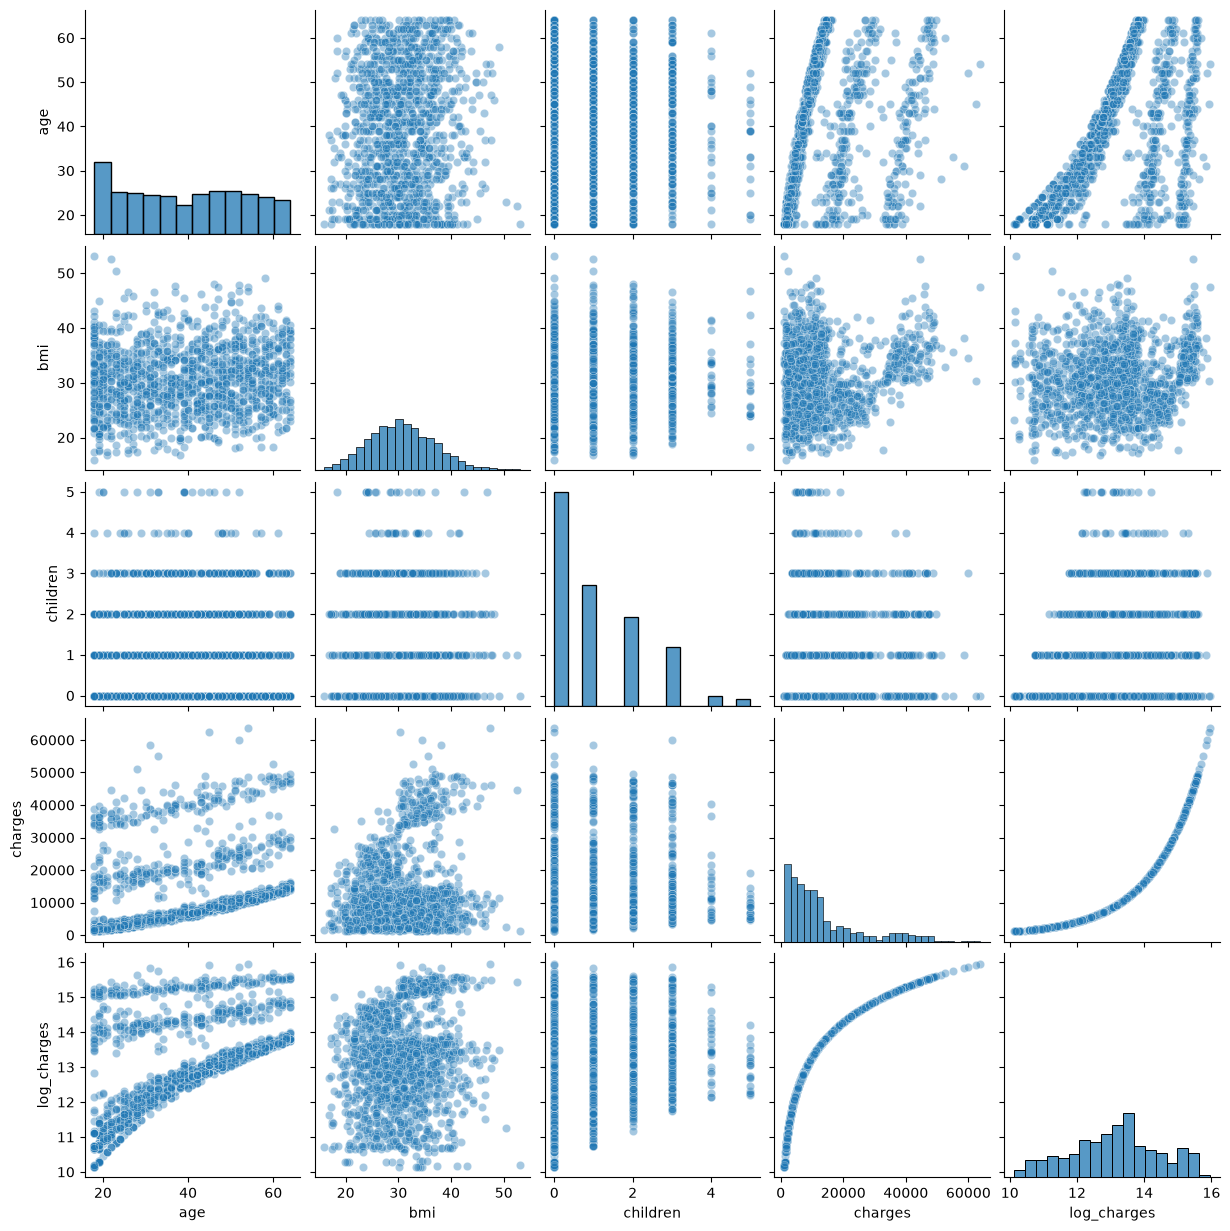

In [8]:
# age vs charges shows 3 distinct bands — smokers form a separate cluster
insurance_numeric = insurance[['age', 'bmi', 'children', 'charges', 'log_charges']]
sns.pairplot(insurance_numeric, kind='scatter', plot_kws={'alpha':0.4})
plt.show()

## 5. Categorical Features vs log_charges


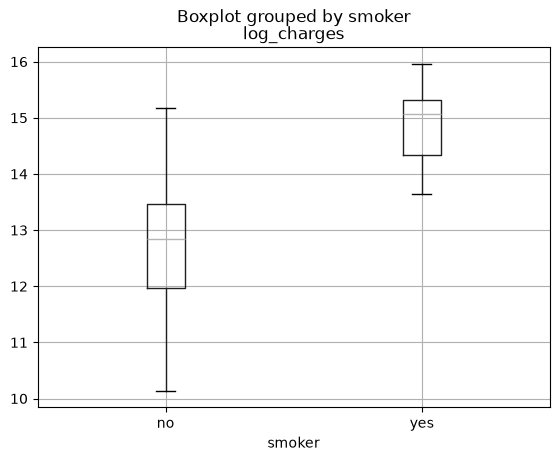

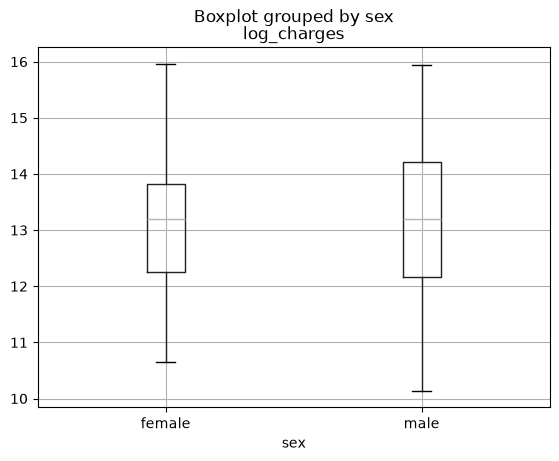

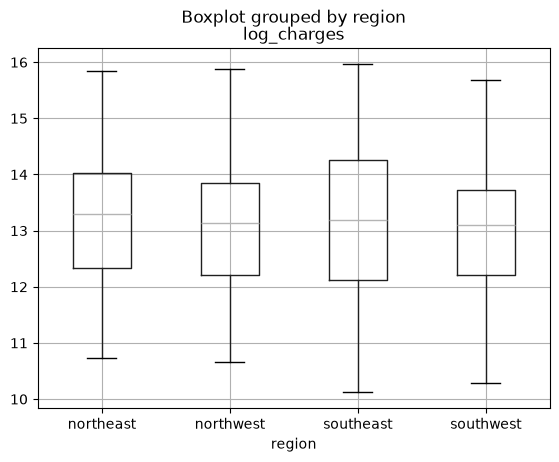

In [9]:
# smoker has strong effect, sex and region minimal
insurance.boxplot(column=["log_charges"], by="smoker")
plt.show()

insurance.boxplot(column=["log_charges"], by="sex")
plt.show()

insurance.boxplot(column=["log_charges"], by="region")
plt.show()